In [56]:
import os

GITHUB_REPO_URL = "https://github.com/kashfihs/Lab4_220129_AIML.git"
REPO_NAME = "K-means"

# Clone repo (skip if already cloned)
if not os.path.exists("K-means"):
    !git clone {GITHUB_REPO_URL}
else:
    print("Repo 'K-means' already exists, skipping clone.")

CUSTOM_DATA_PATH = "K-means/dataset/custom_customers.csv"
MODEL_SAVE_PATH = "K-means/model/220129.pkl"

Repo 'K-means' already exists, skipping clone.


## Step 2 — Install & Import Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


## Step 3 — Load Standard Training Dataset

In [58]:
import pandas as pd

DATASET_URL = "https://raw.githubusercontent.com/kashfihs/Lab4_220129_AIML/main/K-means/datasets/Mall_Customers.csv"

df = pd.read_csv(DATASET_URL)

print("Standard dataset loaded. Shape:", df.shape)
df.head()

Standard dataset loaded. Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 4 — Data Preprocessing (Scaling)

In [59]:
# Select relevant features
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

print("Before scaling:")
print(X.describe().round(2))

# Fit the scaler on standard data — this SAME scaler will be used on custom data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAfter StandardScaler (first 5 rows):")
print(pd.DataFrame(X_scaled, columns=features).head().round(4))

Before scaling:
          Age  Annual Income (k$)  Spending Score (1-100)
count  200.00              200.00                  200.00
mean    38.85               60.56                   50.20
std     13.97               26.26                   25.82
min     18.00               15.00                    1.00
25%     28.75               41.50                   34.75
50%     36.00               61.50                   50.00
75%     49.00               78.00                   73.00
max     70.00              137.00                   99.00

After StandardScaler (first 5 rows):
      Age  Annual Income (k$)  Spending Score (1-100)
0 -1.4246             -1.7390                 -0.4348
1 -1.2810             -1.7390                  1.1957
2 -1.3528             -1.7008                 -1.7159
3 -1.1375             -1.7008                  1.0404
4 -0.5634             -1.6627                 -0.3960


## Step 5 — Optimal K Selection: Elbow Method

In [60]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f"K={k:2d}  |  WCSS = {km.inertia_:.2f}")

K= 1  |  WCSS = 600.00
K= 2  |  WCSS = 389.39
K= 3  |  WCSS = 295.21
K= 4  |  WCSS = 205.23
K= 5  |  WCSS = 168.25
K= 6  |  WCSS = 133.87
K= 7  |  WCSS = 117.01
K= 8  |  WCSS = 103.87
K= 9  |  WCSS = 93.09
K=10  |  WCSS = 82.39


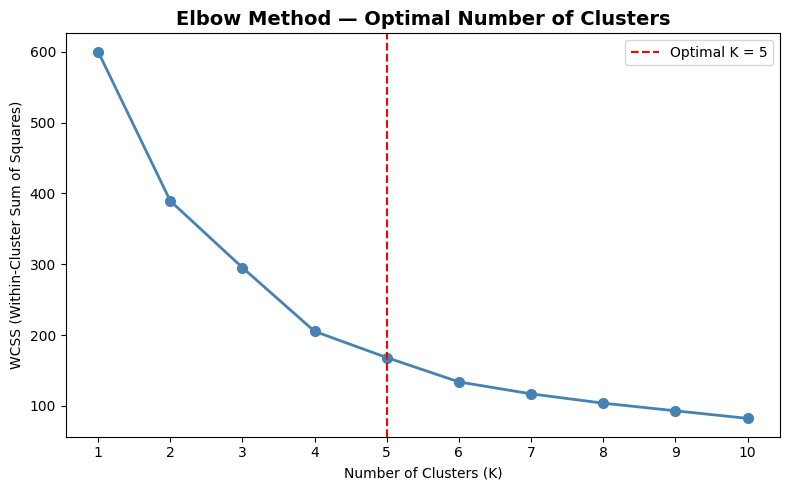

Optimal K = 5 (elbow clearly visible at K=5)


In [61]:
# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), wcss, marker='o', color='steelblue', linewidth=2, markersize=7)
plt.axvline(x=5, color='red', linestyle='--', label='Optimal K = 5')
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(list(K_range))
plt.legend()
plt.tight_layout()
plt.show()
print("Optimal K = 5 (elbow clearly visible at K=5)")

## Step 6 — Fit Final K-Means Model (K=5)

In [62]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_
print(f"Model fitted with K={OPTIMAL_K}")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Model fitted with K=5

Cluster distribution:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


## Step 7 — Save the Trained Model

In [63]:
import os
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
joblib.dump(kmeans, MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH} ✅")

Model saved to: K-means/model/220129.pkl ✅


## Step 8 — Cluster Scatter Plot (2D: Income vs Spending Score)

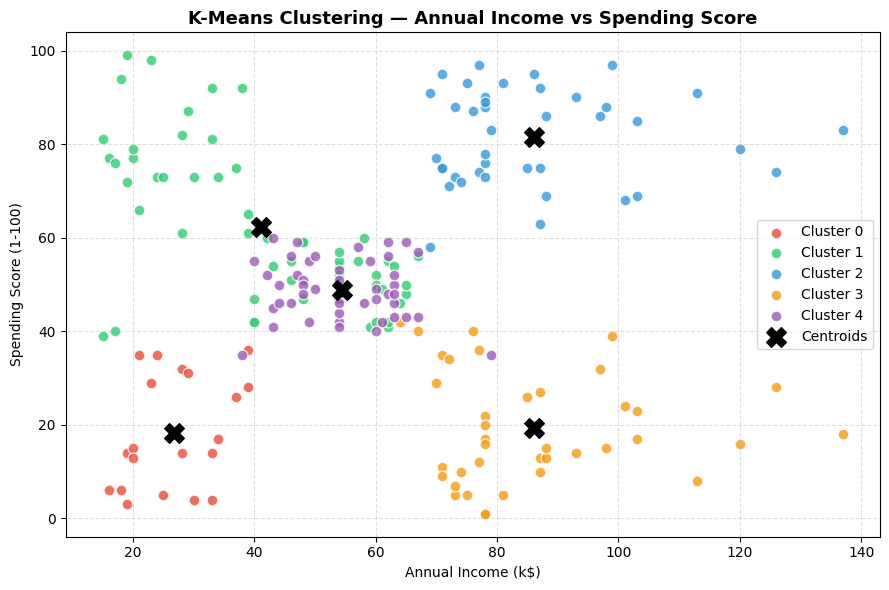

In [64]:
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6']
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2',
                  3: 'Cluster 3', 4: 'Cluster 4'}

fig, ax = plt.subplots(figsize=(9, 6))

for i in range(OPTIMAL_K):
    subset = df[df['Cluster'] == i]
    ax.scatter(subset['Annual Income (k$)'],
               subset['Spending Score (1-100)'],
               c=colors[i], label=cluster_labels[i], s=60, alpha=0.8, edgecolors='white')

# Plot centroids (inverse-transformed back to original scale)
centroids_scaled = kmeans.cluster_centers_
centroids_orig   = scaler.inverse_transform(centroids_scaled)
ax.scatter(centroids_orig[:, 1], centroids_orig[:, 2],
           c='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_title('K-Means Clustering — Annual Income vs Spending Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Step 9 — Real-World Prediction on Custom Data

In [65]:
import os
import pandas as pd

os.makedirs("K-means/datasets", exist_ok=True)

custom_df = pd.DataFrame({
    'CustomerID':[201,202,203,204,205,206,207,208,209,210],
    'Age':[22,35,28,45,31,52,26,40,29,38],
    'Annual Income (k$)':[25,80,40,90,60,30,75,50,45,100],
    'Spending Score (1-100)':[80,20,65,15,50,70,25,55,60,10]
})

custom_df.to_csv("K-means/datasets/custom_customers.csv", index=False)

print("custom_customers.csv created successfully")

custom_customers.csv created successfully


In [66]:
print(custom_df.columns.tolist())

['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [67]:
X_custom = custom_df[features].copy()

X_custom_scaled = scaler.transform(X_custom)

custom_df['Assigned Cluster'] = kmeans.predict(X_custom_scaled)

print(custom_df.head())

   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  \
0         201   22                  25                      80   
1         202   35                  80                      20   
2         203   28                  40                      65   
3         204   45                  90                      15   
4         205   31                  60                      50   

   Assigned Cluster  
0                 1  
1                 3  
2                 1  
3                 3  
4                 1  


In [68]:
# Display as styled DataFrame
from IPython.display import display
result_df = custom_df[['CustomerID', 'Age', 'Annual Income (k$)',
                        'Spending Score (1-100)', 'Assigned Cluster']].copy()
display(result_df.style.background_gradient(subset=['Assigned Cluster'], cmap='Set2'))

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Assigned Cluster
0,201,22,25,80,1
1,202,35,80,20,3
2,203,28,40,65,1
3,204,45,90,15,3
4,205,31,60,50,1
5,206,52,30,70,4
6,207,26,75,25,3
7,208,40,50,55,1
8,209,29,45,60,1
9,210,38,100,10,3
